# Analyse exploratoire — MovieLens (ml-latest-small)

**Systèmes de recommandation — Exercice 1**

## 0. Imports & configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

DATA_DIR = "ml-latest-small"

## 1. Chargement des datasets avec pandas

In [ ]:
movies = pd.read_csv(f"{DATA_DIR}/movies.csv")
ratings = pd.read_csv(f"{DATA_DIR}/ratings.csv")
tags = pd.read_csv(f"{DATA_DIR}/tags.csv")
links = pd.read_csv(f"{DATA_DIR}/links.csv")

# timestamp -> date lisible (utile pour la suite du cours)
ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s")

print("movies :", movies.shape)
print("ratings :", ratings.shape)
print("tags :", tags.shape)
print("links :", links.shape)

movies : (9742, 3)
ratings : (100836, 5)
tags : (3683, 4)
links : (9742, 3)


In [53]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [54]:
ratings.head()

,userId,movieId,rating,timestamp,date
0,1,1,4.0,964982703,2000-07-30 18:45:03
1,1,3,4.0,964981247,2000-07-30 18:20:47
2,1,6,4.0,964982224,2000-07-30 18:37:04
3,1,47,5.0,964983815,2000-07-30 19:03:35
4,1,50,5.0,964982931,2000-07-30 18:48:51


## 2. Combien de films ? Combien d'utilisateurs ?

In [55]:
n_movies_catalogue = movies["movieId"].nunique()
n_movies_rated = ratings["movieId"].nunique()
n_users = ratings["userId"].nunique()

print(f"Films dans movies.csv (catalogue complet)   : {n_movies_catalogue}")
print(f"Films ayant reçu au moins une note           : {n_movies_rated}")
print(f"Utilisateurs distincts (dans ratings.csv)    : {n_users}")

Films dans movies.csv (catalogue complet)   : 9742
Films ayant reçu au moins une note           : 9724
Utilisateurs distincts (dans ratings.csv)    : 610


## 3. Matrice des notes (une ligne par utilisateur, une colonne par film)

Puis calcul de la proportion de notes manquantes.

In [56]:
rating_matrix = ratings.pivot_table(index="userId", columns="movieId", values="rating")
print("Dimensions de la matrice :", rating_matrix.shape)
rating_matrix.iloc[:5, :5]

Dimensions de la matrice : (610, 9724)


movieId,1,2,3,4,5
userId,,,,,
1,4.0,NaN,4.0,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN


In [57]:
n_cells = rating_matrix.shape[0] * rating_matrix.shape[1]
n_missing = rating_matrix.isna().sum().sum()
n_filled = ratings.shape[0]
prop_missing = n_missing / n_cells

print(f"Nombre de cellules total       : {n_cells:,}")
print(f"Nombre de notes présentes      : {n_filled:,}")
print(f"Nombre de valeurs manquantes   : {n_missing:,}")
print(f"Proportion de notes manquantes : {prop_missing:.4%}")
print(f"Proportion de notes présentes  : {1 - prop_missing:.4%}  (= densité de la matrice)")

Nombre de cellules total       : 5,931,640
Nombre de notes présentes      : 100,836
Nombre de valeurs manquantes   : 5,830,804
Proportion de notes manquantes : 98.3000%
Proportion de notes présentes  : 1.7000%  (= densité de la matrice)


## 4. Dictionnaires titre ↔ movieId

In [58]:
title_to_id = dict(zip(movies["title"], movies["movieId"]))
id_to_title = {v: k for k, v in title_to_id.items()}

print(f"Toy Story (1995) -> id {title_to_id['Toy Story (1995)']}")
print(f"id 1 -> titre '{id_to_title[1]}'")

Toy Story (1995) -> id 1
id 1 -> titre 'Toy Story (1995)'


## 5. Étude de la variable note

Paramètres statistiques et représentations graphiques.

In [59]:
ratings['rating'].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [60]:
print(f"Mode        : {ratings['rating'].mode().tolist()}")
print(f"Médiane     : {ratings['rating'].median()}")
print(f"Ecart-type  : {ratings['rating'].std():.3f}")
print(f"Skewness    : {ratings['rating'].skew():.3f}")

Mode        : [4.0]
Médiane     : 3.5
Ecart-type  : 1.043
Skewness    : -0.637


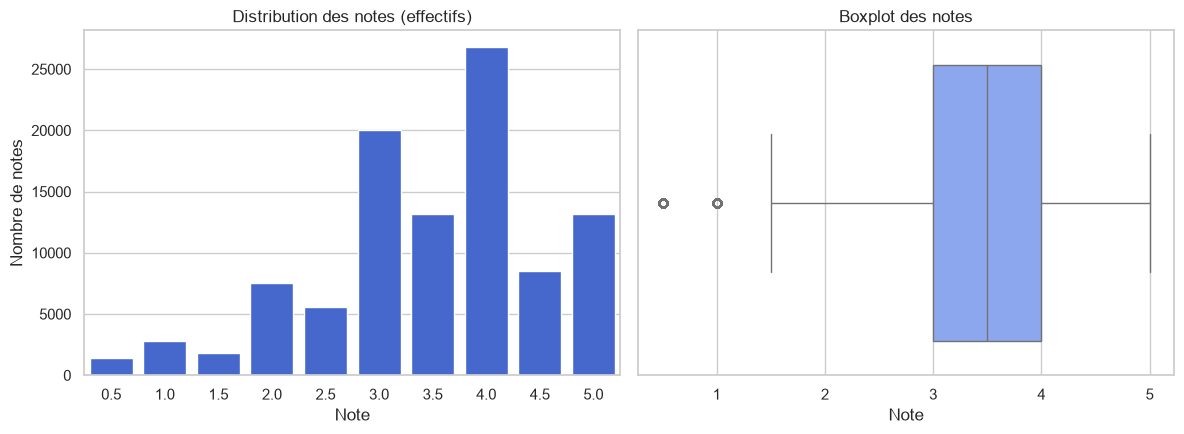

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x="rating", data=ratings, ax=axes[0], color="#2F5DE3")
axes[0].set_title("Distribution des notes (effectifs)")
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Nombre de notes")

sns.boxplot(x=ratings["rating"], ax=axes[1], color="#7DA0FF")
axes[1].set_title("Boxplot des notes")
axes[1].set_xlabel("Note")

plt.tight_layout()
plt.show()

## 6. Nombre de notes reçues par film

Étude de cette variable (stats + graphiques).

In [62]:
nb_notes_par_film = ratings.groupby("movieId")["rating"].count().rename("nb_notes")
nb_notes_par_film.describe()

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: nb_notes, dtype: float64

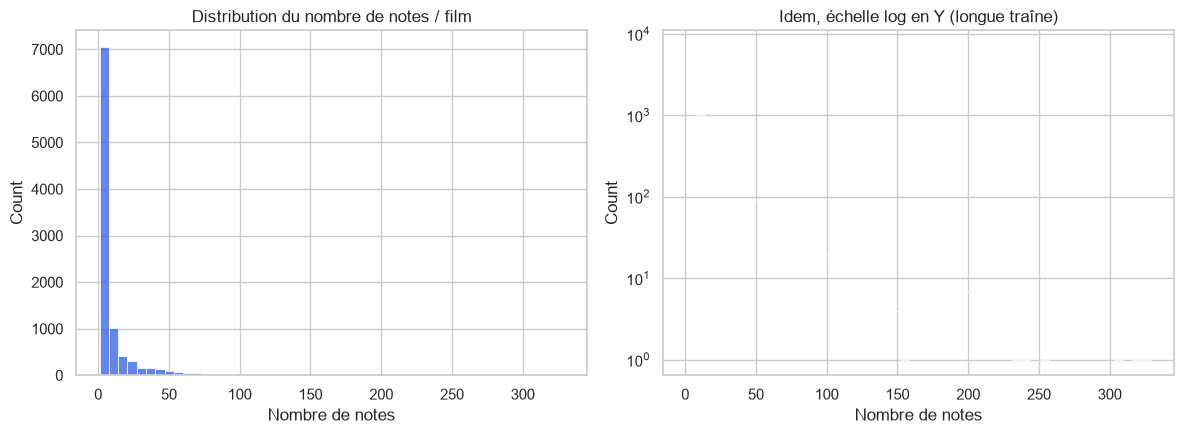

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(nb_notes_par_film, bins=50, ax=axes[0], color="#2F5DE3")
axes[0].set_title("Distribution du nombre de notes / film")
axes[0].set_xlabel("Nombre de notes")

sns.histplot(nb_notes_par_film, bins=50, ax=axes[1], color="#2F5DE3", log_scale=(False, True))
axes[1].set_title("Idem, échelle log en Y (longue traîne)")
axes[1].set_xlabel("Nombre de notes")

plt.tight_layout()
plt.show()

## 7. Rang de chaque film par nombre de notes → Top 50 films les plus notés

In [64]:
rang_popularite = nb_notes_par_film.rank(ascending=False, method="min").rename("rang_popularite")

top50_popularite = (
    nb_notes_par_film.to_frame()
    .join(rang_popularite)
    .join(movies.set_index("movieId")[["title"]])
    .sort_values("rang_popularite")
    .head(50)
)
top50_popularite[["title", "nb_notes", "rang_popularite"]]

,title,nb_notes,rang_popularite
movieId,,,
356,Forrest Gump (1994),329,1.0
318,"Shawshank Redemption, The (1994)",317,2.0
296,Pulp Fiction (1994),307,3.0
593,"Silence of the Lambs, The (1991)",279,4.0
2571,"Matrix, The (1999)",278,5.0
260,Star Wars: Episode IV - A New Hope (1977),251,6.0
480,Jurassic Park (1993),238,7.0
110,Braveheart (1995),237,8.0
589,Terminator 2: Judgment Day (1991),224,9.0


## 8. Note moyenne de chaque film

Étude de cette variable (stats + graphiques).

In [65]:
note_moyenne_par_film = ratings.groupby("movieId")["rating"].mean().rename("note_moyenne")
note_moyenne_par_film.describe()

count    9724.000000
mean        3.262448
std         0.869874
min         0.500000
25%         2.800000
50%         3.416667
75%         3.911765
max         5.000000
Name: note_moyenne, dtype: float64

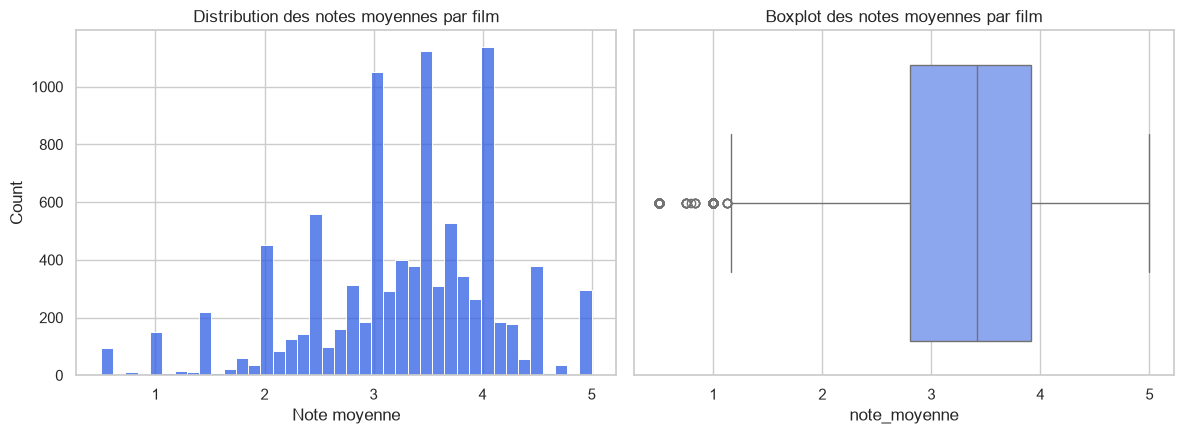

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(note_moyenne_par_film, bins=40, ax=axes[0], color="#2F5DE3")
axes[0].set_title("Distribution des notes moyennes par film")
axes[0].set_xlabel("Note moyenne")

sns.boxplot(x=note_moyenne_par_film, ax=axes[1], color="#7DA0FF")
axes[1].set_title("Boxplot des notes moyennes par film")

plt.tight_layout()
plt.show()

## 9. Rang de chaque film par note moyenne → Top 50 films les mieux notés

⚠️ Attention : sur la note moyenne **brute**, des films avec une seule note à 5.0 dominent le classement. On calcule donc aussi un classement **pondéré** (moyenne bayésienne, façon IMDB) qui est plus représentatif.

In [67]:
rang_qualite = note_moyenne_par_film.rank(ascending=False, method="min").rename("rang_qualite")

top50_qualite_brut = (
    note_moyenne_par_film.to_frame()
    .join(rang_qualite)
    .join(nb_notes_par_film)
    .join(movies.set_index("movieId")[["title"]])
    .sort_values("rang_qualite")
    .head(50)
)
top50_qualite_brut[["title", "note_moyenne", "nb_notes", "rang_qualite"]]

,title,note_moyenne,nb_notes,rang_qualite
movieId,,,,
2075,Mephisto (1981),5.0,1,1.0
86721,Idiots and Angels (2008),5.0,1,1.0
86668,Louis Theroux: Law & Disorder (2008),5.0,1,1.0
85295,Scooby-Doo! Curse of the Lake Monster (2010),5.0,1,1.0
103602,Craig Ferguson: I'm Here To Help (2013),5.0,1,1.0
83969,Down Argentine Way (1940),5.0,1,1.0
176601,Black Mirror,5.0,1,1.0
3567,Bossa Nova (2000),5.0,1,1.0
27373,61* (2001),5.0,1,1.0


In [68]:
# Version pondérée (bonus) : évite que les films avec 1 seule note à 5.0 dominent
C = ratings["rating"].mean()          # note moyenne globale
m = 20                                # seuil minimal de notes pour être crédible

stats_film = nb_notes_par_film.to_frame().join(note_moyenne_par_film)
stats_film["note_ponderee"] = (
    (stats_film["nb_notes"] / (stats_film["nb_notes"] + m)) * stats_film["note_moyenne"]
    + (m / (stats_film["nb_notes"] + m)) * C
)

top50_qualite_ponderee = (
    stats_film.join(movies.set_index("movieId")[["title"]])
    .sort_values("note_ponderee", ascending=False)
    .head(50)
)
top50_qualite_ponderee[["title", "note_moyenne", "nb_notes", "note_ponderee"]]

,title,note_moyenne,nb_notes,note_ponderee
movieId,,,,
318,"Shawshank Redemption, The (1994)",4.429022,317,4.373980
858,"Godfather, The (1972)",4.289062,192,4.214770
2959,Fight Club (1999),4.272936,218,4.208114
260,Star Wars: Episode IV - A New Hope (1977),4.231076,251,4.177237
50,"Usual Suspects, The (1995)",4.237745,204,4.172014
527,Schindler's List (1993),4.225000,220,4.164713
1221,"Godfather: Part II, The (1974)",4.259690,129,4.157927
296,Pulp Fiction (1994),4.197068,307,4.154529
1196,Star Wars: Episode V - The Empire Strikes Back...,4.215640,211,4.153814


## 10. Reprise des questions 6 à 9, mais par genre

Un film peut avoir plusieurs genres (séparés par `|`) → on "explose" la table pour avoir une ligne par (film, genre).

In [69]:
movies_genres = movies.copy()
movies_genres["genres"] = movies_genres["genres"].str.split("|")
movies_genres = movies_genres.explode("genres")
movies_genres = movies_genres[movies_genres["genres"] != "(no genres listed)"]

ratings_genres = ratings.merge(movies_genres[["movieId", "genres"]], on="movieId")

print(f"Nombre de genres distincts : {movies_genres['genres'].nunique()}")
sorted(movies_genres["genres"].unique())

Nombre de genres distincts : 19


['Action',
 'Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'IMAX',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western']

### 10.6 — Nombre de notes par genre

In [70]:
nb_notes_par_genre = (
    ratings_genres.groupby("genres")["rating"].count()
    .rename("nb_notes")
    .sort_values(ascending=False)
)
nb_notes_par_genre

genres
Drama          41928
Comedy         39053
Action         30635
Thriller       26452
Adventure      24161
Romance        18124
Sci-Fi         17243
Crime          16681
Fantasy        11834
Children        9208
Mystery         7674
Horror          7291
Animation       6988
War             4859
IMAX            4145
Musical         4138
Western         1930
Documentary     1219
Film-Noir        870
Name: nb_notes, dtype: int64

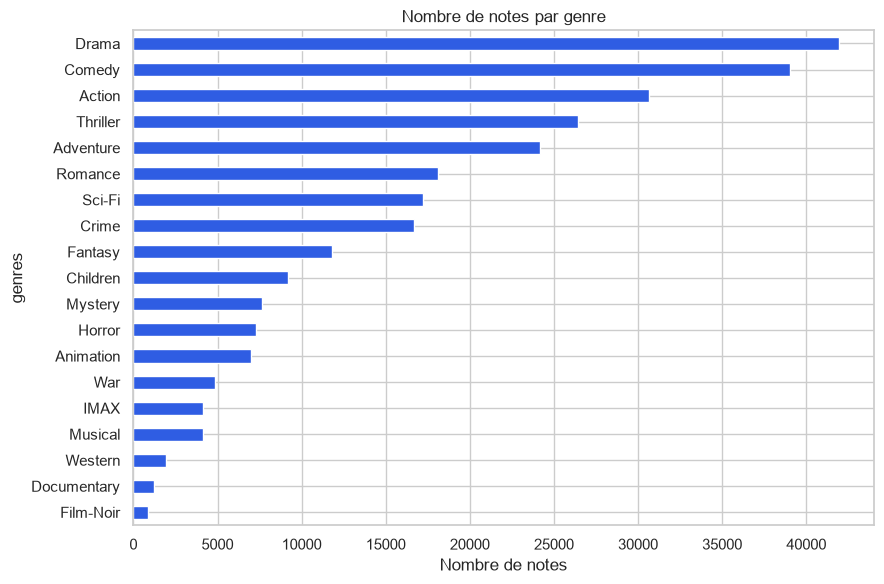

In [71]:
fig, ax = plt.subplots(figsize=(9, 6))
nb_notes_par_genre.sort_values().plot(kind="barh", ax=ax, color="#2F5DE3")
ax.set_title("Nombre de notes par genre")
ax.set_xlabel("Nombre de notes")
plt.tight_layout()
plt.show()

### 10.7 — Classement des genres par nombre de notes

In [72]:
rang_popularite_genre = nb_notes_par_genre.rank(ascending=False, method="min")
rang_popularite_genre.sort_values()

genres
Drama           1.0
Comedy          2.0
Action          3.0
Thriller        4.0
Adventure       5.0
Romance         6.0
Sci-Fi          7.0
Crime           8.0
Fantasy         9.0
Children       10.0
Mystery        11.0
Horror         12.0
Animation      13.0
War            14.0
IMAX           15.0
Musical        16.0
Western        17.0
Documentary    18.0
Film-Noir      19.0
Name: nb_notes, dtype: float64

### 10.8 — Note moyenne par genre

In [73]:
note_moyenne_par_genre = (
    ratings_genres.groupby("genres")["rating"].mean()
    .rename("note_moyenne")
    .sort_values(ascending=False)
)
note_moyenne_par_genre

genres
Film-Noir      3.920115
War            3.808294
Documentary    3.797785
Crime          3.658294
Drama          3.656184
Mystery        3.632460
Animation      3.629937
IMAX           3.618335
Western        3.583938
Musical        3.563678
Adventure      3.508609
Romance        3.506511
Thriller       3.493706
Fantasy        3.491001
Sci-Fi         3.455721
Action         3.447984
Children       3.412956
Comedy         3.384721
Horror         3.258195
Name: note_moyenne, dtype: float64

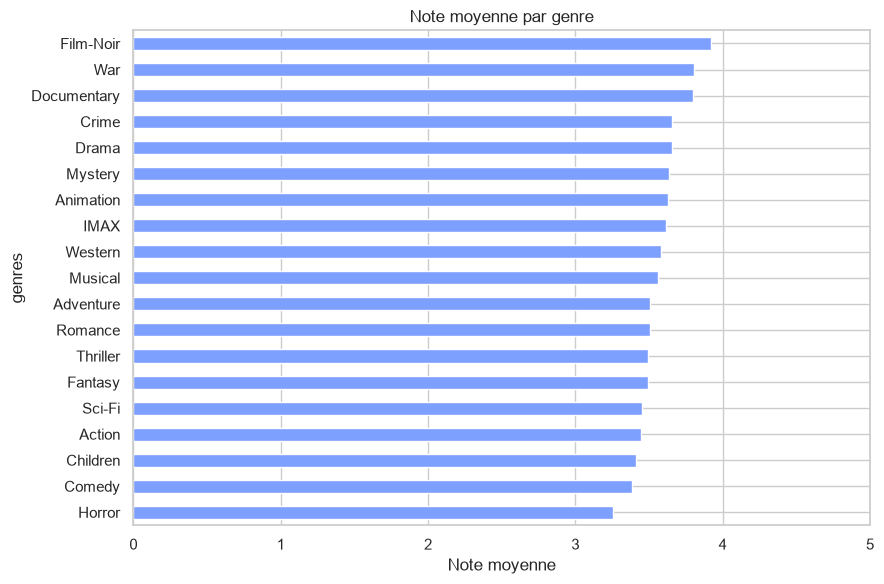

In [74]:
fig, ax = plt.subplots(figsize=(9, 6))
note_moyenne_par_genre.sort_values().plot(kind="barh", ax=ax, color="#7DA0FF")
ax.set_title("Note moyenne par genre")
ax.set_xlabel("Note moyenne")
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()

### 10.9 — Classement des genres par note moyenne

In [75]:
rang_qualite_genre = note_moyenne_par_genre.rank(ascending=False, method="min")
rang_qualite_genre.sort_values()

genres
Film-Noir       1.0
War             2.0
Documentary     3.0
Crime           4.0
Drama           5.0
Mystery         6.0
Animation       7.0
IMAX            8.0
Western         9.0
Musical        10.0
Adventure      11.0
Romance        12.0
Thriller       13.0
Fantasy        14.0
Sci-Fi         15.0
Action         16.0
Children       17.0
Comedy         18.0
Horror         19.0
Name: note_moyenne, dtype: float64